# Exploratory Data Analysis on Retail Sales Data
### Superstore Sales Dataset — OIBSIP Data Analytics Internship (Level 1, Task 1)

**Author:** Vineet Pandey

**Objective:** Perform a thorough Exploratory Data Analysis (EDA) on a retail sales dataset to uncover
patterns, customer behaviour trends, and actionable business insights.

**Dataset:** Superstore Sales dataset (2015–2018), 9,800 orders across the US, covering `Sales`,
`Order_Date`, `Ship_Date`, `Ship_Mode`, `Segment`, `Category`, `Sub_Category`, `Region`, `State`, `City`, and product details.

> **Note on scope:** This particular export of the Superstore dataset does not include customer
> age or gender fields (nor `Quantity`/`Profit`/`Discount`, which appear in some other Superstore
> versions). Wherever the task checklist calls for "customer demographics," we use **Customer
> Segment** (Consumer / Corporate / Home Office) as the available demographic proxy, and note this
> substitution explicitly.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', None)


## 1. Load Data & Initial Inspection

In [2]:
df = pd.read_csv("superstore.csv", encoding="latin1")
print("Shape:", df.shape)
df.head()


Shape: (9800, 18)


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


In [3]:
print("Column data types:\n")
print(df.dtypes)


Column data types:

Row_ID             int64
Order_ID             str
Order_Date           str
Ship_Date            str
Ship_Mode            str
Customer_ID          str
Customer_Name        str
Segment              str
Country              str
City                 str
State                str
Postal_Code      float64
Region               str
Product_ID           str
Category             str
Sub_Category         str
Product_Name         str
Sales            float64
dtype: object


In [4]:
print("Null values per column:\n")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Null values per column:

Row_ID            0
Order_ID          0
Order_Date        0
Ship_Date         0
Ship_Mode         0
Customer_ID       0
Customer_Name     0
Segment           0
Country           0
City              0
State             0
Postal_Code      11
Region            0
Product_ID        0
Category          0
Sub_Category      0
Product_Name      0
Sales             0
dtype: int64

Duplicate rows: 0


**Observation:** The dataset has 9,800 rows and 18 columns. Only `Postal_Code` has missing
values (11 rows — all belonging to Burlington, Vermont, a known gap in this dataset). There are no
duplicate rows, so no de-duplication is needed. Dates are stored as text in `DD/MM/YYYY` format
(verified by cross-checking `Ship_Date` always falling a few days after `Order_Date`, consistent
with each order's `Ship_Mode`), so we parse them accordingly below.

## 2. Data Preparation

In [5]:
# Parse dates correctly (DD/MM/YYYY format)
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'], dayfirst=True)

# Derived time features
df['Order_Year'] = df['Order_Date'].dt.year
df['Order_Month'] = df['Order_Date'].dt.month
df['Order_YearMonth'] = df['Order_Date'].dt.to_period('M').astype(str)
df['Order_Quarter'] = df['Order_Date'].dt.to_period('Q').astype(str)

# Derived operational feature: shipping delay in days
df['Ship_Delay_Days'] = (df['Ship_Date'] - df['Order_Date']).dt.days

df[['Order_Date','Ship_Date','Order_Year','Order_Month','Order_Quarter','Ship_Delay_Days']].head()


,Order_Date,Ship_Date,Order_Year,Order_Month,Order_Quarter,Ship_Delay_Days
0,2017-11-08,2017-11-11,2017,11,2017Q4,3
1,2017-11-08,2017-11-11,2017,11,2017Q4,3
2,2017-06-12,2017-06-16,2017,6,2017Q2,4
3,2016-10-11,2016-10-18,2016,10,2016Q4,7
4,2016-10-11,2016-10-18,2016,10,2016Q4,7


## 3. Descriptive Statistics

In [6]:
print("Descriptive statistics for Sales:\n")
print(df['Sales'].describe())

print("\nMean:   {:.2f}".format(df['Sales'].mean()))
print("Median: {:.2f}".format(df['Sales'].median()))
print("Mode:   {:.2f}".format(df['Sales'].mode()[0]))
print("Std Dev:{:.2f}".format(df['Sales'].std()))


Descriptive statistics for Sales:

count     9800.000000
mean       230.769059
std        626.651875
min          0.444000
25%         17.248000
50%         54.490000
75%        210.605000
max      22638.480000
Name: Sales, dtype: float64

Mean:   230.77
Median: 54.49
Mode:   12.96
Std Dev:626.65


**Observation:** Sales per line item range from \$0.44 to \$22,638, with a mean of \$230.77
but a much lower median of \$54.49. This large gap between mean and median, combined with a high
standard deviation (\$626.65), tells us the distribution is heavily right-skewed — most orders are
small-ticket items, while a small number of large orders pull the average up substantially.

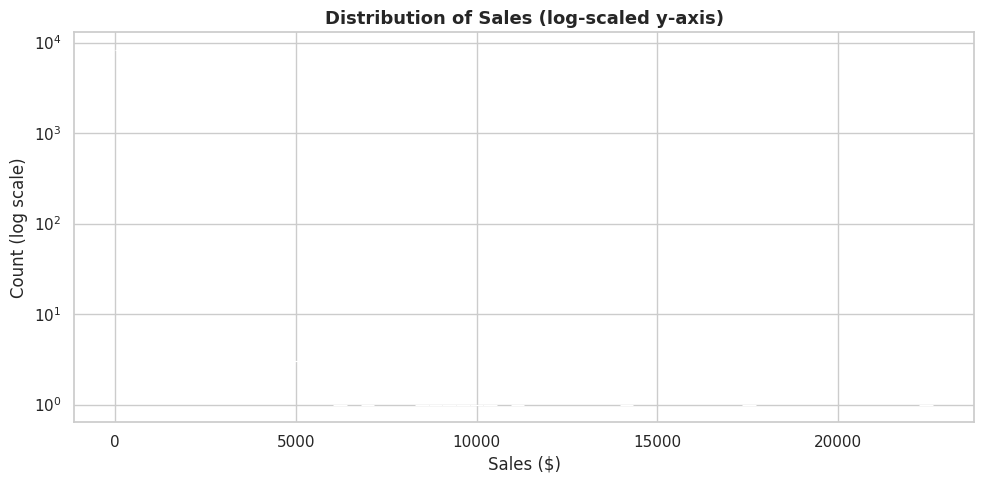

In [7]:
plt.figure(figsize=(10,5))
sns.histplot(df['Sales'], bins=60, log_scale=(False, True), color="#4C72B0")
plt.title("Distribution of Sales (log-scaled y-axis)")
plt.xlabel("Sales ($)")
plt.ylabel("Count (log scale)")
plt.tight_layout()
plt.show()


## 4. Time Series Analysis

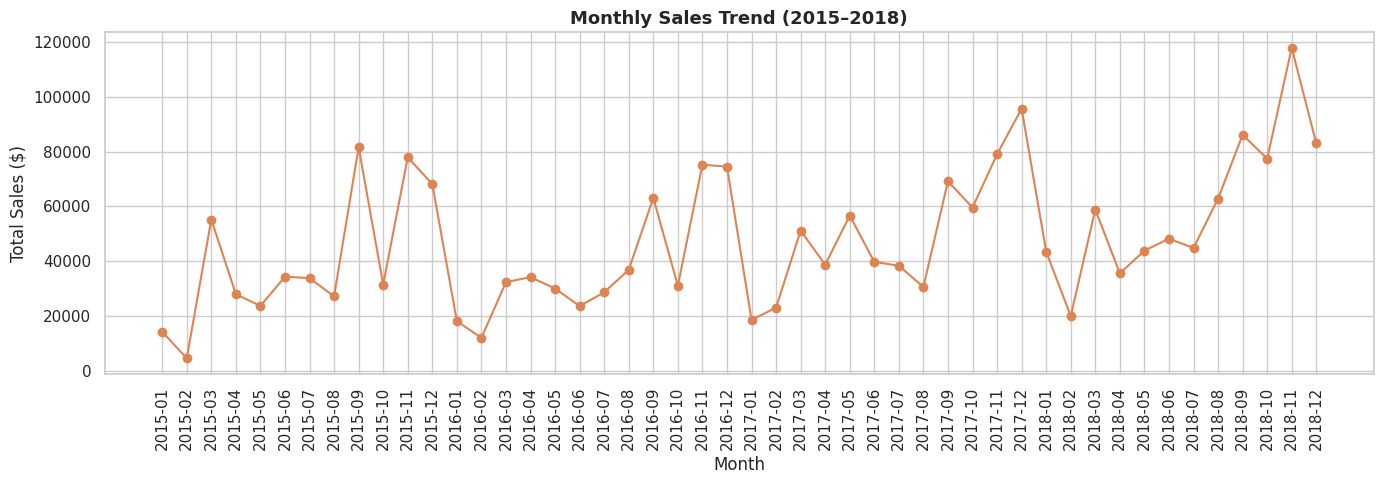

In [8]:
monthly_sales = df.groupby('Order_YearMonth')['Sales'].sum().reset_index()

plt.figure(figsize=(14,5))
plt.plot(monthly_sales['Order_YearMonth'], monthly_sales['Sales'], marker='o', color="#DD8452")
plt.xticks(rotation=90)
plt.title("Monthly Sales Trend (2015–2018)")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.tight_layout()
plt.show()


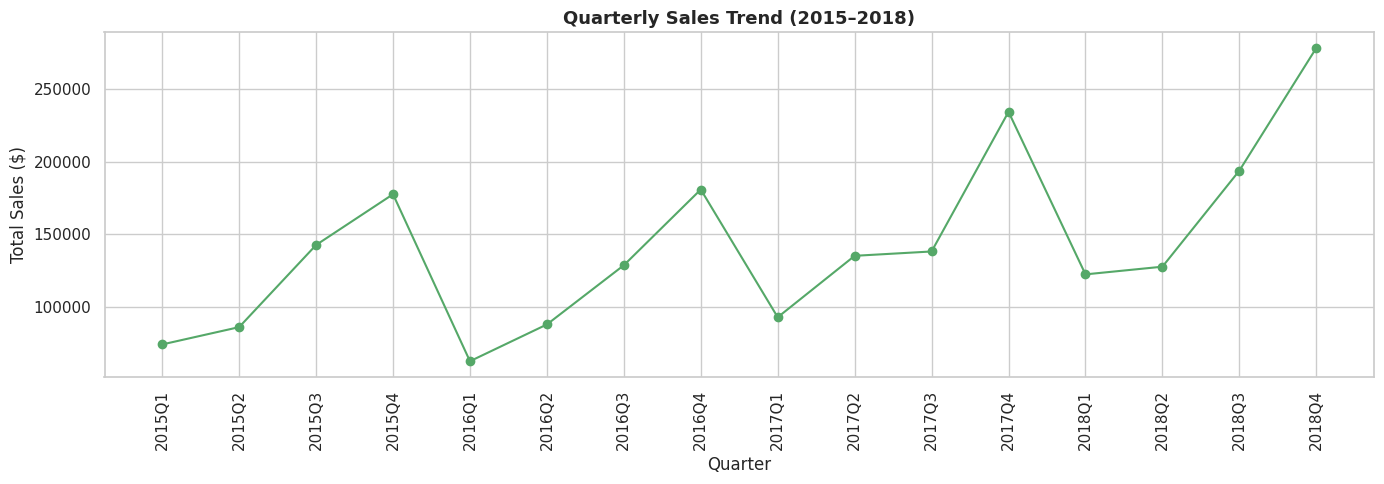

In [9]:
quarterly_sales = df.groupby('Order_Quarter')['Sales'].sum().reset_index()

plt.figure(figsize=(14,5))
plt.plot(quarterly_sales['Order_Quarter'], quarterly_sales['Sales'], marker='o', color="#55A868")
plt.xticks(rotation=90)
plt.title("Quarterly Sales Trend (2015–2018)")
plt.xlabel("Quarter")
plt.ylabel("Total Sales ($)")
plt.tight_layout()
plt.show()


**Observation:** Sales show a clear seasonal pattern — dips are visible in early months of each
year (Jan–Feb), and strong peaks consistently appear toward Q4 (Nov–Dec), suggesting a holiday-season
buying effect. The quarterly view confirms Q4 is consistently the strongest quarter across all four
years, and there is an overall upward trend in quarterly revenue from 2015 to 2018, indicating the
business is growing year-over-year, not just riding seasonality.

## 5. Customer Segment Analysis

> As noted above, this dataset doesn't contain age or gender fields, so we analyse the
> **Customer Segment** (Consumer / Corporate / Home Office) as the closest available demographic
> breakdown, alongside geographic (Region) distribution.

/tmp/ipykernel_141/3733370629.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=seg_sales.index, y=seg_sales.values, ax=axes[1], palette="Set2")


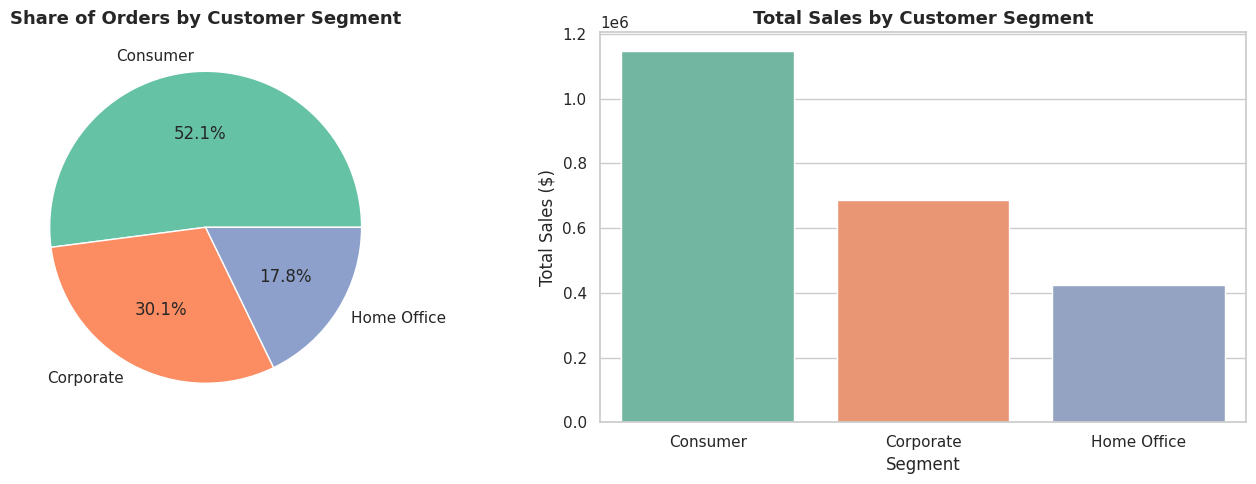

In [10]:
seg_counts = df['Segment'].value_counts()
seg_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].pie(seg_counts, labels=seg_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette("Set2"))
axes[0].set_title("Share of Orders by Customer Segment")

sns.barplot(x=seg_sales.index, y=seg_sales.values, ax=axes[1], palette="Set2")
axes[1].set_title("Total Sales by Customer Segment")
axes[1].set_ylabel("Total Sales ($)")

plt.tight_layout()
plt.show()


/tmp/ipykernel_141/4277410532.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_sales.index, y=region_sales.values, palette="mako")


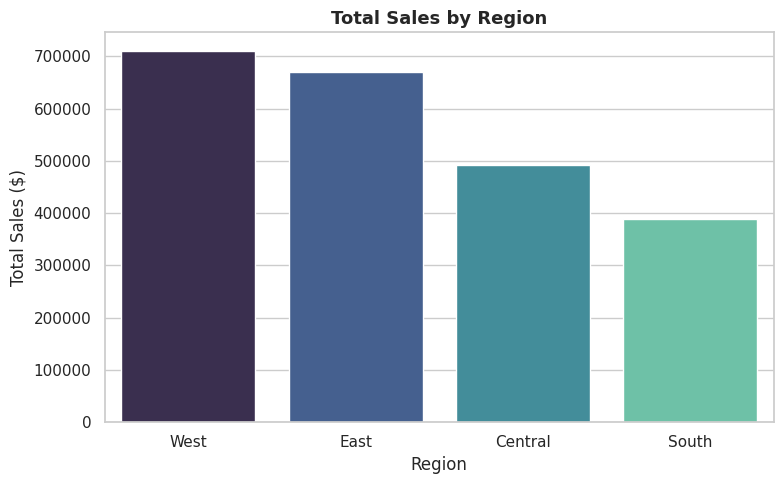

In [11]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=region_sales.index, y=region_sales.values, palette="mako")
plt.title("Total Sales by Region")
plt.ylabel("Total Sales ($)")
plt.tight_layout()
plt.show()


**Observation:** The **Consumer** segment accounts for roughly half of all orders and the
largest share of total revenue, making it the backbone of the business, followed by Corporate and
then Home Office. Geographically, the **West** and **East** regions generate noticeably more
revenue than the **Central** and **South** regions, suggesting either stronger market penetration
or higher-value customers concentrated on the coasts.

## 6. Product Analysis

/tmp/ipykernel_141/3686059256.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_products.index, x=top_products.values, palette="crest")


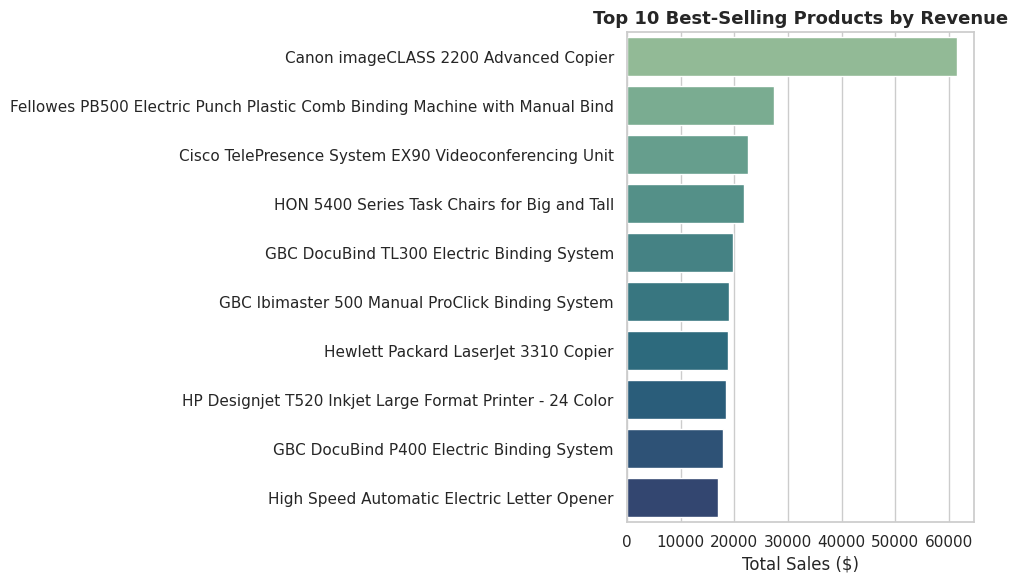

In [12]:
top_products = df.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(y=top_products.index, x=top_products.values, palette="crest")
plt.title("Top 10 Best-Selling Products by Revenue")
plt.xlabel("Total Sales ($)")
plt.ylabel("")
plt.tight_layout()
plt.show()


/tmp/ipykernel_141/3871109127.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_sales.index, y=cat_sales.values, palette="flare")


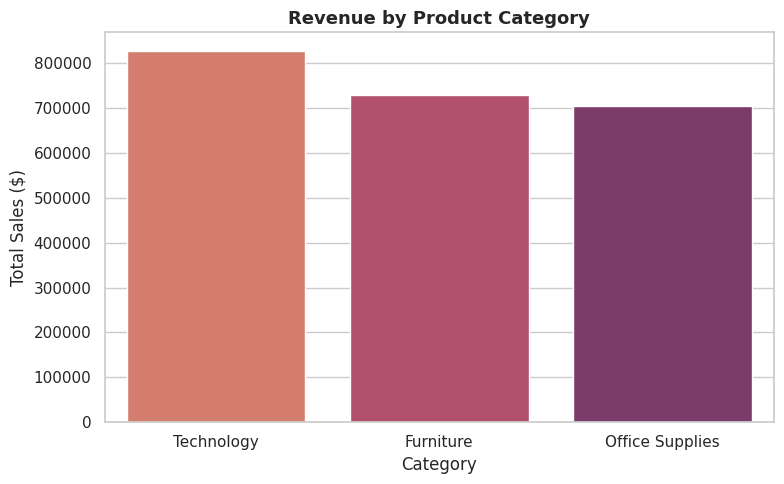

In [13]:
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=cat_sales.index, y=cat_sales.values, palette="flare")
plt.title("Revenue by Product Category")
plt.ylabel("Total Sales ($)")
plt.tight_layout()
plt.show()


/tmp/ipykernel_141/118584306.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=subcat_sales.index, x=subcat_sales.values, palette="flare")


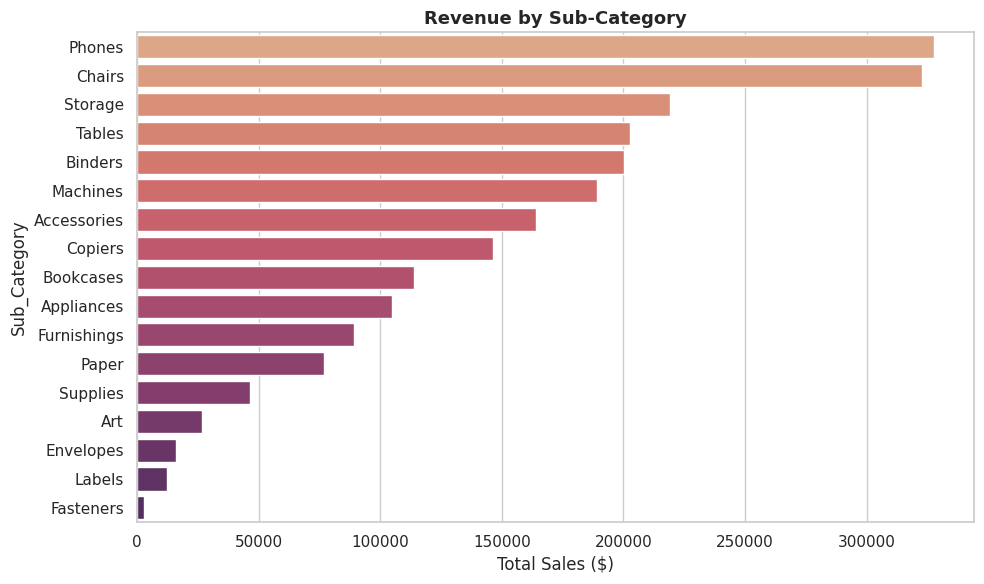

In [14]:
subcat_sales = df.groupby('Sub_Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(y=subcat_sales.index, x=subcat_sales.values, palette="flare")
plt.title("Revenue by Sub-Category")
plt.xlabel("Total Sales ($)")
plt.tight_layout()
plt.show()


**Observation:** **Technology** and **Office Supplies** generate the most total revenue among
the three categories, though at the sub-category level, a handful of items — office chairs, phones,
and high-end copiers/machines — dominate the top-10 product list. This "long tail" pattern (a small
set of high-value products driving a disproportionate share of revenue) is typical of retail and
suggests these top products deserve prioritized inventory and marketing attention.

## 7. Correlation Heatmap

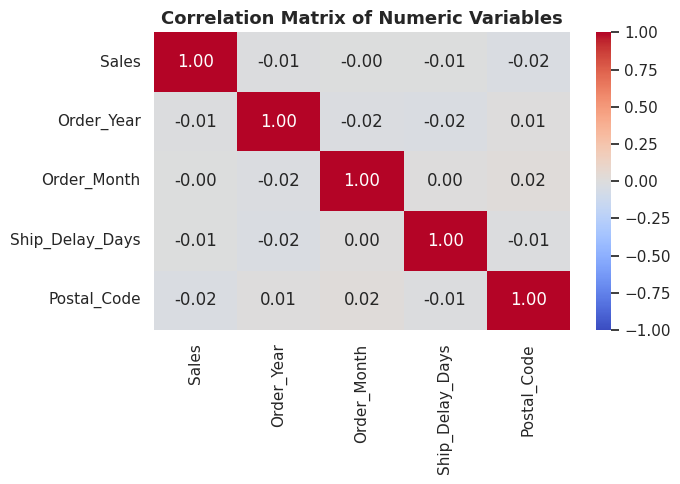

In [15]:
numeric_df = df[['Sales', 'Order_Year', 'Order_Month', 'Ship_Delay_Days', 'Postal_Code']].dropna()

plt.figure(figsize=(7,5))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Numeric Variables")
plt.tight_layout()
plt.show()


**Observation:** None of the available numeric variables correlate strongly with `Sales` —
correlations with `Order_Year`, `Order_Month`, `Ship_Delay_Days`, and `Postal_Code` are all close to
zero. This tells us sale size is driven mainly by *what* is bought (category/product) and *who* buys
it (segment), rather than by timing or shipping-related factors — a useful negative finding that
rules out timing/logistics as revenue drivers.

## 8. Additional Insight: Shipping Delay by Ship Mode

This is not part of the standard checklist items above — it's an additional, less obvious
angle: are customers actually getting the delivery speed implied by the `Ship_Mode` they paid for?

/tmp/ipykernel_141/2433494869.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=delay_by_mode.index, y=delay_by_mode.values, palette="viridis")


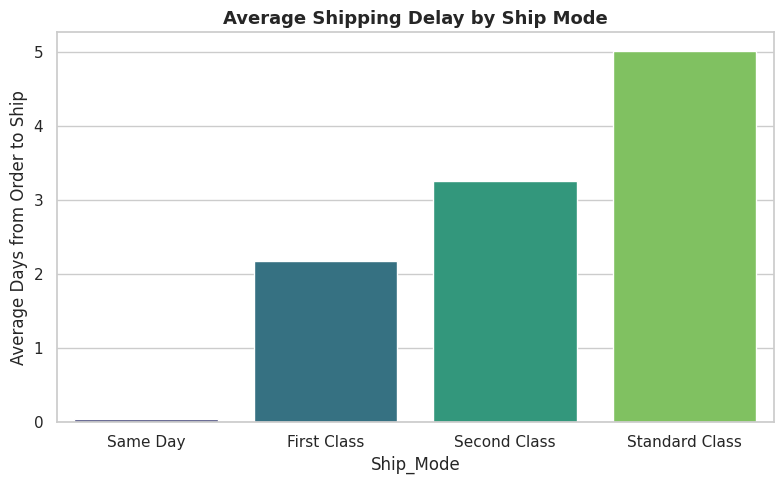

Ship_Mode
Same Day          0.04
First Class       2.18
Second Class      3.25
Standard Class    5.01
Name: Ship_Delay_Days, dtype: float64


In [16]:
delay_by_mode = df.groupby('Ship_Mode')['Ship_Delay_Days'].mean().sort_values()

plt.figure(figsize=(8,5))
sns.barplot(x=delay_by_mode.index, y=delay_by_mode.values, palette="viridis")
plt.title("Average Shipping Delay by Ship Mode")
plt.ylabel("Average Days from Order to Ship")
plt.tight_layout()
plt.show()

print(delay_by_mode.round(2))


**Observation:** The ship-mode ordering behaves exactly as expected — **Same Day** has the
shortest average delay, followed by **First Class**, **Second Class**, and **Standard Class** with
the longest. This confirms the shipping tiers are functioning correctly and reliably, which is a
good operational health check, though it also means there's no hidden "Sales" relationship — see
Section 7's near-zero correlation confirming that faster shipping doesn't correlate with bigger
orders.

## 9. Conclusion & Business Recommendations

Based on the analysis above, we recommend:

1. **Double down on Q4 seasonal demand.** Sales consistently spike in Q4 (Nov–Dec) every year.
   The business should plan inventory build-up, staffing, and marketing campaigns ahead of this
   window, especially for the top-performing sub-categories identified in Section 6.

2. **Prioritize the Consumer segment and West/East regions in marketing spend.** These segments
   and regions already generate the most revenue; targeted loyalty programs or upsell campaigns
   here are likely to have the highest ROI, while the Central and South regions may warrant
   investigation into why they underperform (pricing, competition, marketing reach).

3. **Protect and expand the top 10 "hero" products.** A small number of products (led by
   high-ticket Technology and Furniture items) contribute disproportionately to revenue. Ensuring
   these are always in stock, well-promoted, and monitored for competitor pricing should be an
   operational priority.

4. **Shipping speed is operationally healthy but not a lever for revenue growth.** Since shipping
   delay shows no correlation with sale size, marketing messaging or discounts tied to "faster
   shipping" are unlikely to move average order value — budget is better spent on product mix and
   segment targeting instead.
